# Preprocessing Task

- I left the output of each cell so you can check your solution and know what the expected output should look like.
- If your code is correct but produces slightly different results from mine, that’s totally fine. This rarely happens, but if it does, it will be minor and will be taken into consideration.

# Importing


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv(r"C:\Users\mnour\Downloads\Problem_1\house_prices.csv")
df.head()   

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
df.shape





(1460, 81)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Handle Null Values

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include=['object', 'category']).columns

# print counts
print("#Num_cols:", len(num_cols))
print("#Cat_cols:", len(cat_cols))


#Num_cols: 38
#Cat_cols: 43


- <b> features to be removed ---> 80%  is nan 
- <b> features to filled --------> less than 80 % 
- <b> observation to be removed --> less than 3% 

In [25]:
null_df = df.isnull().sum().reset_index()
null_df.columns = ['Feature', 'MissingValues']
null_df = null_df.sort_values(by='MissingValues', ascending=False)

print(pd.DataFrame(null_df.head(10)))
removed=[]
filled=[]
observed_removed=[]

def handle_nulls(df):
    null_counts = df.isnull().sum()
    total_rows = len(df)
    
    for col in df.columns:
        null_count = null_counts[col]
        null_percentage = (null_count / total_rows) * 100
        
        if null_percentage >= 80:
            df.drop(columns=[col], inplace=True)
            removed.append(col)
        elif 3 < null_percentage < 80:
            if df[col].dtype in ['int64', 'float64']:
             mean_value = df[col].mean()
             df[col].fillna(mean_value, inplace=True)
             filled.append(col)
            elif df[col].dtype in ['object', 'category']:
             mode_value = df[col].mode()[0]
             df[col].fillna(mode_value, inplace=True)
             filled.append(col) 

        elif null_percentage <= 3:
            df.dropna(subset=[col], inplace=True)
            observed_removed.append(col)


handle_nulls(df)

print("Columns removed due to high null values:", removed)
print("Columns filled with mean due to moderate null values:", filled)
print("Columns with rows dropped due to low null values:", observed_removed)
# write function calculate the number of null values in each Feature (column) and Feature has 80% or higher null values drop Feature
# if null count is > 3% and < 80%  fill it by mean 
# if null count is < 3% remove this row that contain this null value 

         Feature  MissingValues
72        PoolQC           1453
74   MiscFeature           1406
6          Alley           1369
73         Fence           1179
25    MasVnrType            872
57   FireplaceQu            690
3    LotFrontage            259
63    GarageQual             81
60  GarageFinish             81
58    GarageType             81
Columns removed due to high null values: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Columns filled with mean due to moderate null values: ['LotFrontage', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
Columns with rows dropped due to low null values: ['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond

# Redundant Handling

### Automated function for both categorical and numircal data

In [26]:
def most_redundant_counts_sorted(df):
    result = {}
    for col in df.columns:
        result[col] = df[col].value_counts(dropna=False).max()

    sorted_result = dict(sorted(result.items(), key=lambda x: x[1], reverse=True))
    return sorted_result
most_redundant_counts_sorted(df)
    


{'Utilities': 1411,
 'Street': 1406,
 'PoolArea': 1405,
 'Condition2': 1397,
 '3SsnPorch': 1389,
 'RoofMatl': 1387,
 'LowQualFinSF': 1387,
 'Heating': 1386,
 'MiscVal': 1363,
 'KitchenAbvGr': 1361,
 'GarageCond': 1361,
 'GarageQual': 1344,
 'LandSlope': 1335,
 'CentralAir': 1331,
 'BsmtHalfBath': 1330,
 'Functional': 1322,
 'PavedDrive': 1303,
 'BsmtCond': 1301,
 'Electrical': 1300,
 'ScreenPorch': 1296,
 'MasVnrType': 1269,
 'LandContour': 1267,
 'BsmtFinType2': 1246,
 'BsmtFinSF2': 1246,
 'ExterCond': 1239,
 'SaleType': 1224,
 'Condition1': 1220,
 'EnclosedPorch': 1209,
 'BldgType': 1189,
 'SaleCondition': 1159,
 'MSZoning': 1111,
 'RoofStyle': 1103,
 'FireplaceQu': 1030,
 'LotConfig': 1015,
 'BsmtExposure': 944,
 'GarageType': 926,
 'LotShape': 886,
 'HalfBath': 872,
 'ExterQual': 871,
 'MasVnrArea': 828,
 'BsmtFullBath': 815,
 '2ndFlrSF': 796,
 'GarageCars': 793,
 'OverallCond': 792,
 'BedroomAbvGr': 790,
 'FullBath': 738,
 'HeatingQC': 725,
 'WoodDeckSF': 723,
 'KitchenQual': 705,

In [27]:
threshold = 0.8
rows = df.shape[0]

cols_to_drop = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True).values[0]
    

    if top_freq >= threshold:
        cols_to_drop.append(col)

print("Columns to drop:", cols_to_drop)

# Drop them
df = df.drop(columns=cols_to_drop)

Columns to drop: ['Street', 'LandContour', 'Utilities', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'RoofMatl', 'MasVnrType', 'ExterCond', 'BsmtCond', 'BsmtFinType2', 'BsmtFinSF2', 'Heating', 'CentralAir', 'Electrical', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr', 'Functional', 'GarageQual', 'GarageCond', 'PavedDrive', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'SaleType', 'SaleCondition']


In [28]:
corr = df.select_dtypes(include=['number']).corr()
pd.DataFrame(corr)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MoSold,YrSold,SalePrice
Id,1.000000,0.010816,-0.012445,-0.034357,-0.031729,0.017332,-0.016396,-0.023834,-0.047418,-0.005680,...,0.026706,-0.017027,-0.003027,0.016094,0.018983,-0.029800,-0.005046,0.026508,-0.004209,-0.024651
MSSubClass,0.010816,1.000000,-0.360014,-0.138298,0.038952,-0.063240,0.032256,0.043906,0.023024,-0.067783,...,0.030657,-0.040128,0.077865,-0.034897,-0.094523,-0.014568,-0.005684,-0.016463,-0.026526,-0.082281
LotFrontage,-0.012445,-0.360014,1.000000,0.305272,0.232351,-0.054635,0.114914,0.078828,0.179330,0.215487,...,0.323671,0.235190,0.061591,0.269574,0.324954,0.075353,0.134402,0.005484,0.006464,0.333477
LotArea,-0.034357,-0.138298,0.305272,1.000000,0.104763,-0.002941,0.014163,0.010765,0.104010,0.213450,...,0.189107,0.268960,-0.025568,0.153812,0.180207,0.172281,0.083860,0.001070,-0.012886,0.264803
OverallQual,-0.031729,0.038952,0.232351,0.104763,1.000000,-0.121155,0.570266,0.540129,0.409656,0.211652,...,0.438254,0.392978,0.518342,0.607663,0.561612,0.230274,0.297678,0.064301,-0.024251,0.786765
OverallCond,0.017332,-0.063240,-0.054635,-0.002941,-0.121155,1.000000,-0.389624,0.057361,-0.134961,-0.057034,...,-0.058852,-0.030047,-0.318043,-0.193904,-0.163341,-0.013206,-0.041823,-0.008530,0.048668,-0.093567
YearBuilt,-0.016396,0.032256,0.114914,0.014163,0.570266,-0.389624,1.000000,0.593163,0.311745,0.242714,...,0.091792,0.143433,0.781869,0.536963,0.475678,0.225469,0.185426,0.008403,-0.014693,0.518736
YearRemodAdd,-0.023834,0.043906,0.078828,0.010765,0.540129,0.057361,0.593163,1.000000,0.172112,0.110541,...,0.189216,0.100277,0.619468,0.423161,0.369665,0.199144,0.218889,0.015944,0.029968,0.500266
MasVnrArea,-0.047418,0.023024,0.179330,0.104010,0.409656,-0.134961,0.311745,0.172112,1.000000,0.259291,...,0.283266,0.241914,0.247464,0.363992,0.370982,0.157566,0.124018,-0.009909,-0.005249,0.474525
BsmtFinSF1,-0.005680,-0.067783,0.215487,0.213450,0.211652,-0.057034,0.242714,0.110541,0.259291,1.000000,...,0.043425,0.250394,0.141824,0.215661,0.288913,0.196236,0.098352,-0.020850,0.020268,0.368849


#### If we have 2 highly correlated features (corr > 0.7), we drop one of them (the variable which is less correlated to the response variable (Output column) )

In [29]:
pairs = []

for col in corr.columns:
    for row in corr.index:
        if col != row and abs(corr.loc[row, col]) > threshold:
            pairs.append([row, col, corr.loc[row, col]])
pairs_df = pd.DataFrame(pairs, columns=['Feature1', 'Feature2', 'Correlation'])
print(pd.DataFrame(pairs_df))

       Feature1      Feature2  Correlation
0      1stFlrSF   TotalBsmtSF     0.894018
1   TotalBsmtSF      1stFlrSF     0.894018
2  TotRmsAbvGrd     GrLivArea     0.827693
3     GrLivArea  TotRmsAbvGrd     0.827693
4    GarageArea    GarageCars     0.880618
5    GarageCars    GarageArea     0.880618


# Handling Outliers 
- lower band = q1 - (1.5*IQR)
- Upper band = q3 + (1.5*IQR)

In [30]:
outlier={}
def remove_outliers(df):

    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        if col in pairs_df['Feature1'].values:
            outlier[col]=df[(df[col] < Q1 - 1.5 * (Q3 - Q1)) | (df[col] > Q3 + 1.5 * (Q3 - Q1))][col].count()
            print(f"Outliers in {col}: {outlier[col]}")
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df = remove_outliers(df)



Outliers in TotalBsmtSF: 12
Outliers in 1stFlrSF: 6
Outliers in GrLivArea: 17
Outliers in TotRmsAbvGrd: 5
Outliers in GarageCars: 2
Outliers in GarageArea: 3


# Skewness Handling
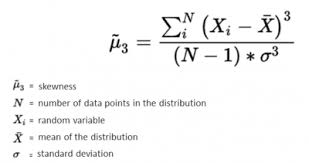


In [31]:
skewness_dict = {}
def calculate_skewness(df):

    for col in df.select_dtypes(include=['number']).columns:
        skewness = df[col].skew()
        skewness_dict[col] = skewness
    return skewness_dict
skewness_values = calculate_skewness(df)

for key, value in skewness_values.items():
    print(f"{key}: {value}")


Id: 0.0016238145058506245
MSSubClass: 0.9109294375624328
LotFrontage: 0.026429027364569604
LotArea: 0.1591931255924466
OverallQual: 0.045808030927592905
OverallCond: 0.705159596311018
YearBuilt: -0.4556146171225765
YearRemodAdd: -0.3852495642774652
MasVnrArea: 1.5322277905626127
BsmtFinSF1: 0.5568399053944071
BsmtUnfSF: 0.6700038688786053
TotalBsmtSF: 0.3973837518759717
1stFlrSF: 0.555086575930841
2ndFlrSF: 0.8934510562649245
GrLivArea: 0.3912711808051272
BsmtFullBath: 0.5146717955207719
FullBath: 0.11576792115161343
HalfBath: 0.8955207737448724
BedroomAbvGr: -0.3828964919633596
TotRmsAbvGrd: 0.17789741436104362
Fireplaces: 0.598542076428492
GarageYrBlt: -0.6198685201408529
GarageCars: -0.4647819804310111
GarageArea: -0.11498133027874109
WoodDeckSF: 1.0127093064263362
OpenPorchSF: 1.2174482639272677
MoSold: 0.25252424469580537
YrSold: 0.13352793455543063
SalePrice: 0.47776911484409457


# Log Transformation
> X = log(1 + | X | )     
this is the equation 

In [32]:
# Features that have absolute skewness > 1 do for it Log tranformation 
for i in skewness_dict:
    if abs(skewness_dict[i]) > 1:
        df[i] = np.log1p(df[i]) 
        print(f"{i} : {skewness_dict[i]}")


MasVnrArea : 1.5322277905626127
WoodDeckSF : 1.0127093064263362
OpenPorchSF : 1.2174482639272677


# Transform categorical features 

In [33]:
# cat_cols ordinal or nominal?
ordinal_cats = ['BsmtQual', 'LotShape', 'HeatingQC', 'BsmtFinType1',  'ExterQual', 
                 'KitchenQual', 'BsmtExposure', 'GarageFinish','MasVnrType']
nominal_cats = ['HouseStyle', 'LotConfig', 'RoofStyle', 'GarageType', 'Exterior1st', 
                'Foundation', 'MSZoning', 'Exterior2nd', 'Neighborhood','FireplaceQu']
category=[]
for i in df.columns:
    if df[i].dtype in ["object", "category"]:
        category.append(i)  
print(category)        
        

['MSZoning', 'LotShape', 'LotConfig', 'Neighborhood', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish']


In [34]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,HouseStyle,OverallQual,...,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MoSold,YrSold,SalePrice
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,2Story,7,...,Attchd,2003.000000,RFn,2,548,0.000000,4.127134,2,2008,208500
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,2Story,7,...,Attchd,2001.000000,RFn,2,608,0.000000,3.761200,9,2008,223500
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,2Story,7,...,Detchd,1998.000000,Unf,3,642,0.000000,3.583519,2,2006,140000
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,2Story,8,...,Attchd,2000.000000,RFn,3,836,5.262690,4.442651,12,2008,250000
5,6,50,RL,85.0,14115,IR1,Inside,Mitchel,1.5Fin,5,...,Attchd,1993.000000,Unf,2,480,3.713572,3.433987,10,2009,143000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1451,90,RL,60.0,9000,Reg,FR2,NAmes,2Story,5,...,Attchd,1978.596413,Unf,0,0,3.496508,3.828641,9,2009,136000
1451,1452,20,RL,78.0,9262,Reg,Inside,Somerst,1Story,8,...,Attchd,2008.000000,Fin,3,840,0.000000,3.610918,5,2009,287090
1454,1455,20,FV,62.0,7500,Reg,Inside,Somerst,1Story,7,...,Attchd,2004.000000,RFn,2,400,0.000000,4.736198,10,2009,185000
1455,1456,60,RL,62.0,7917,Reg,Inside,Gilbert,2Story,6,...,Attchd,1999.000000,RFn,2,460,0.000000,3.713572,8,2007,175000


In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
df[ordinal_cats] = df[ordinal_cats].apply(LabelEncoder().fit_transform)
df = pd.get_dummies(df, columns=nominal_cats, drop_first=True)
df[ordinal_cats].head()


KeyError: "['MasVnrType'] not in index"

# Transform Numerical features 
> I want you apply only Min-Max Scaling for all numerical columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        df[i] = MinMaxScaler().fit_transform(df[[i]])


In [ ]:
# print Your final data frame here 
# data.head()
df.head()

,Id,MSSubClass,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrType,...,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA
0,0.000000,0.4,0.4375,0.400706,1.0,0.714286,0.333333,0.949580,0.883333,0.333333,...,False,False,False,False,False,False,False,False,False,False
2,0.001372,0.4,0.4750,0.602391,0.0,0.714286,0.333333,0.932773,0.866667,0.333333,...,False,False,False,False,False,False,False,False,False,True
3,0.002058,0.5,0.3750,0.479939,0.0,0.714286,0.333333,0.210084,0.333333,1.000000,...,False,False,False,False,False,False,False,True,False,False
4,0.002743,0.4,0.6750,0.819203,0.0,0.857143,0.333333,0.924370,0.833333,0.333333,...,False,False,False,False,False,False,False,False,False,True
5,0.003429,0.3,0.6875,0.808759,0.0,0.428571,0.333333,0.865546,0.750000,1.000000,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 868 entries, 0 to 1458
Columns: 116 entries, Id to FireplaceQu_TA
dtypes: bool(78), float64(38)
memory usage: 330.6 KB
